# Complete KNN Pipeline (From Scratch)

## Step 1: Loads CIFAR-10 Dataset

In [113]:
#imports modules
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image
import warnings

In [22]:
#function to extract images from CIFAR-10 readme
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [27]:
#function to extract images from CIFAR-10 readme - extracts only data and labels in x,y format
my_keys = [b'data',b'labels']
def unpickle_mod(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
        dict = {key:dict[key] for key in my_keys}
    return dict

In [23]:
#reads and 'unfolds' data from CIFAR-10 using helper function above
base_dir = r"/home/disk_2/Coding/CS231N/datasets/CIFAR10/cifar-10-python/cifar-10-batches-py/"
b1 = unpickle(base_dir + r"data_batch_1") 
b2 = unpickle(base_dir + r"data_batch_2")
b3 = unpickle(base_dir + r"data_batch_3")
b4 = unpickle(base_dir + r"data_batch_4")
b5 = unpickle(base_dir + r"data_batch_5")

In [28]:
#reads and 'unfolds' data from CIFAR-10 using helper function above - only x and y components
b1_mod = unpickle_mod(base_dir + r"data_batch_1") 
b2_mod = unpickle_mod(base_dir + r"data_batch_2")
b3_mod = unpickle_mod(base_dir + r"data_batch_3")
b4_mod = unpickle_mod(base_dir + r"data_batch_4")
b5_mod = unpickle_mod(base_dir + r"data_batch_5")

In [50]:
#reads english labels corresponding to numeric labels
eng_labels = unpickle(base_dir + r"batches.meta") 
label_map = {}
for i in range(10):
    label_map[i] = dict(zip(eng_labels[b'label_names']),range(10)) [j for j in eng_labels[b'label_names']]

In [55]:
label_map = dict(zip(range(10),eng_labels[b'label_names']))
label_map

{0: b'airplane',
 1: b'automobile',
 2: b'bird',
 3: b'cat',
 4: b'deer',
 5: b'dog',
 6: b'frog',
 7: b'horse',
 8: b'ship',
 9: b'truck'}

## Step 2: Visualizing the dataset

b'truck'


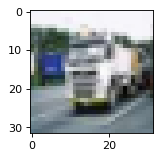

In [211]:
#set index to pull out an image
idx = 1000

#pull out image and label 
ex = b1_mod[b'data'][idx]
ex_label = b1_mod[b'labels'][idx]

#resize image from CIFAR10 data into 3-D numpy array -- note here that numpy follows (depth, rows, columns) nomenclature
ex_new = np.reshape(ex, (3,32,32))
# print(ex_new.shape)
# print(ex.shape)

#prints label and the image
print(label_map[ex_label])
plt.figure(figsize = (2,2), dpi = 80)
plt.imshow(ex_new.transpose(1, 2, 0))
plt.show()